Task 1: Term Deposit Subscription Prediction

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, f1_score
)
import shap
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
df = pd.read_csv(r"C:\Users\user\Downloads\bank+marketing\bank\bank-full.csv", sep=";")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
# Check column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [8]:
# Statistical summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


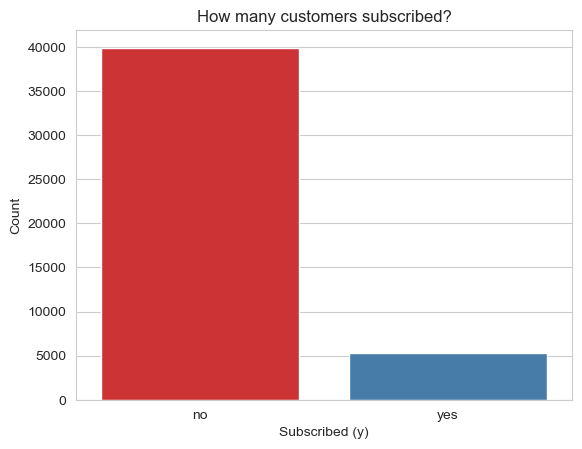

In [39]:
# Check target column — how many said YES vs NO
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)

# Plot it
sns.countplot(x='y', data=df, palette='Set1')
plt.title('How many customers subscribed?')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.show()

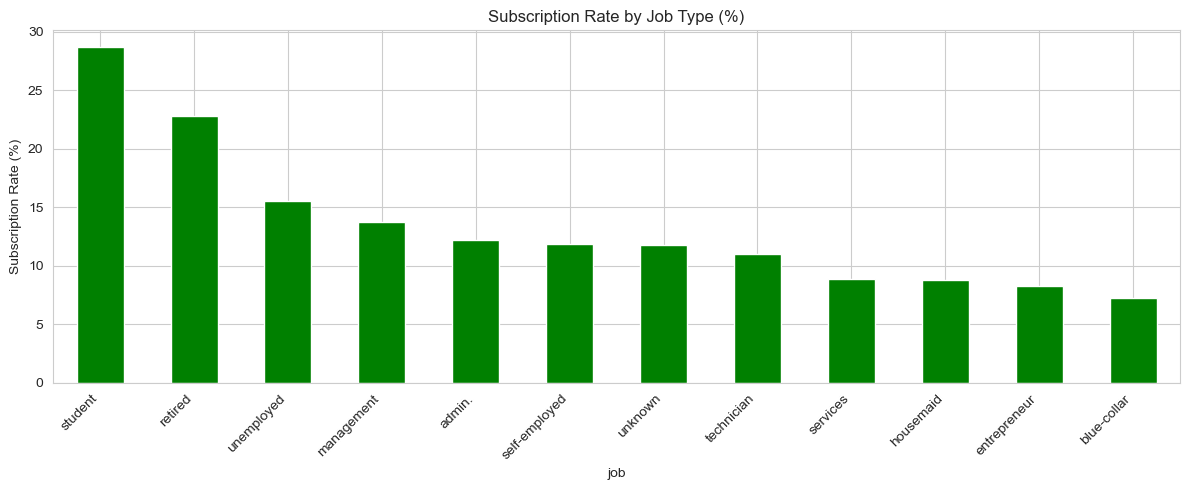

In [38]:
# Subscription rate by Job type
job_sub = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

job_sub.plot(kind='bar', color='green', figsize=(12, 5))
plt.title('Subscription Rate by Job Type (%)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()

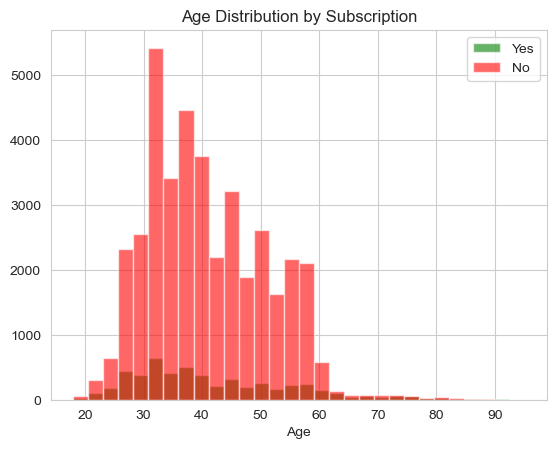

In [17]:
# Age distribution by subscription
df[df['y'] == 'yes']['age'].hist(alpha=0.6, bins=30, color='green', label='Yes')
df[df['y'] == 'no']['age'].hist(alpha=0.6, bins=30, color='red', label='No')
plt.title('Age Distribution by Subscription')
plt.xlabel('Age')
plt.legend()
plt.show()

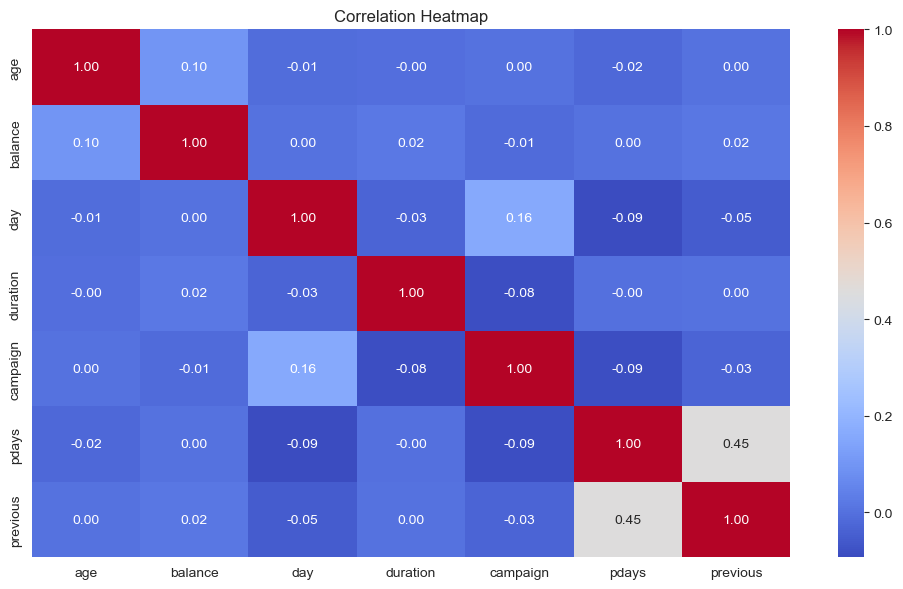

In [18]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [19]:
# Make a copy to keep original safe
df_clean = df.copy()

# Replace 'unknown' with NaN
df_clean.replace('unknown', np.nan, inplace=True)

# Fill missing values with most common value in each column
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Missing values after cleaning: 52124


In [20]:
# Encode target: yes -> 1, no -> 0
df_clean['y'] = df_clean['y'].map({'yes': 1, 'no': 0})
print(df_clean['y'].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [21]:
# Encode all text columns into numbers
le = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("All columns are now numeric!")
df_clean.head()

All columns are now numeric!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [22]:
X = df_clean.drop('y', axis=1)   # Features (input)
y = df_clean['y']                 # Target (output)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45211, 16)
Target shape: (45211,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 36168
Testing rows:  9043


In [24]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained!")

Logistic Regression trained!


In [25]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained!")

Random Forest trained!


In [26]:
# Classification Report (F1-Score, Precision, Recall)
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_pred, target_names=['No', 'Yes']))

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_pred, target_names=['No', 'Yes']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

          No       0.90      0.98      0.94      7985
         Yes       0.57      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043

RANDOM FOREST
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7985
         Yes       0.66      0.42      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



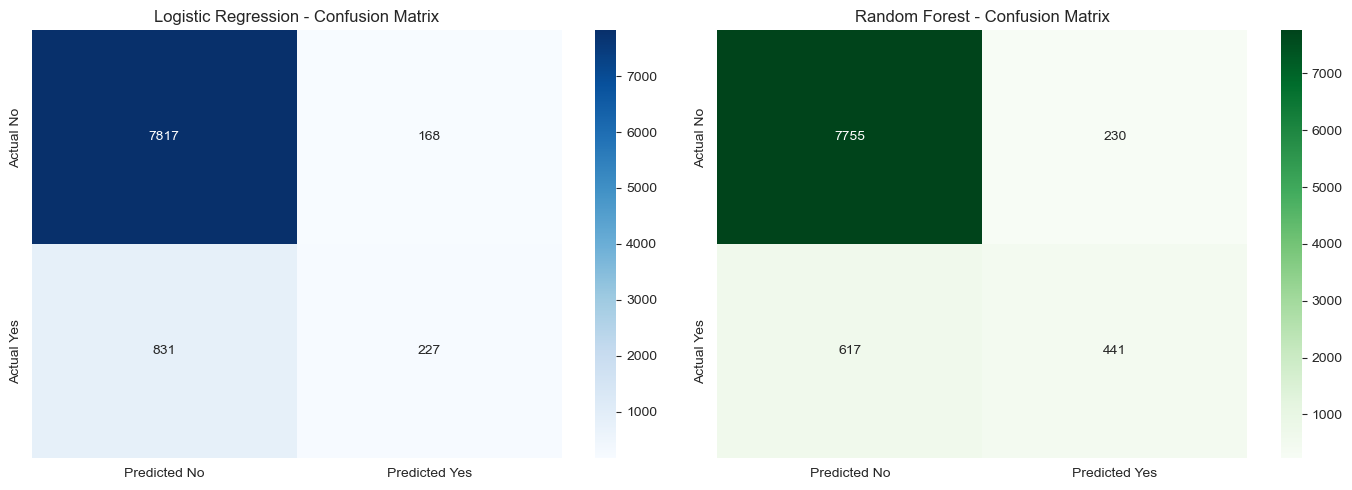

In [27]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
axes[0].set_title('Logistic Regression - Confusion Matrix')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
axes[1].set_title('Random Forest - Confusion Matrix')

plt.tight_layout()
plt.show()

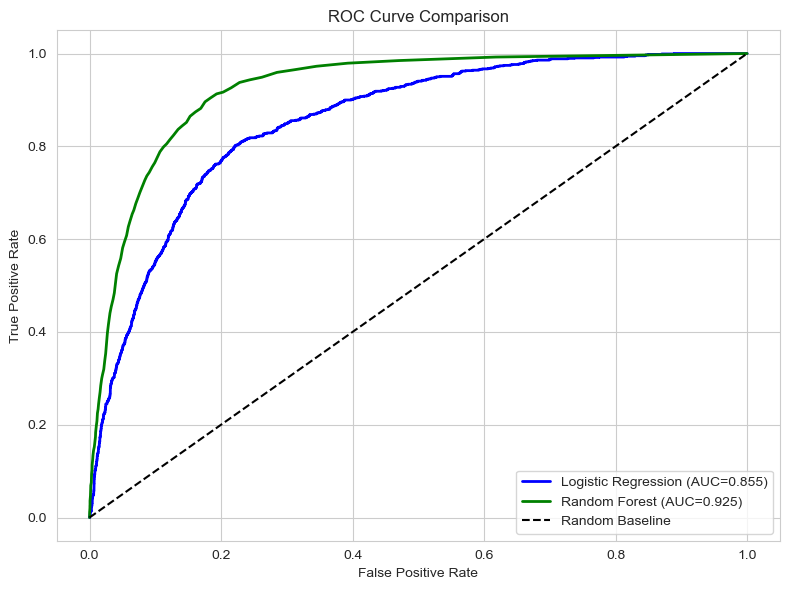

In [28]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)

auc_lr = roc_auc_score(y_test, lr_pred_proba)
auc_rf = roc_auc_score(y_test, rf_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', color='blue', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

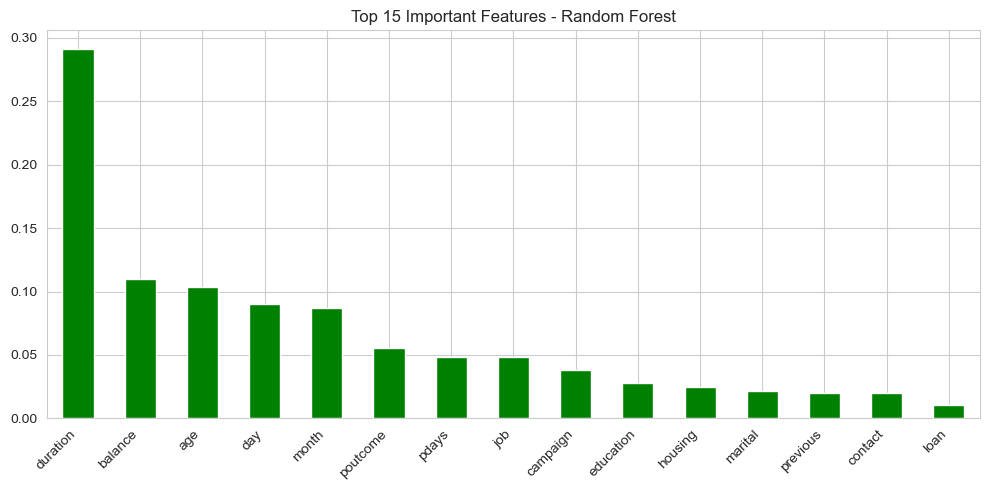

In [32]:
# Feature Importance
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).head(15).plot(kind='bar', color='green', figsize=(10, 5))
plt.title('Top 15 Important Features - Random Forest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
# Create SHAP explainer (takes 1-2 minutes)
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(rf_model)

# Use only 500 rows for speed
X_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_sample)
print("SHAP values ready!")

Creating SHAP explainer...
SHAP values ready!


In [42]:
# Check the shape first
print("Type:", type(shap_values))
print("Length:", len(shap_values))
print("Shape of shap_values[0]:", shap_values[0].shape)
print("Shape of shap_values[1]:", shap_values[1].shape)
print("Shape of X_sample:", X_sample.shape)

Type: <class 'numpy.ndarray'>
Length: 500
Shape of shap_values[0]: (16, 2)
Shape of shap_values[1]: (16, 2)
Shape of X_sample: (500, 16)


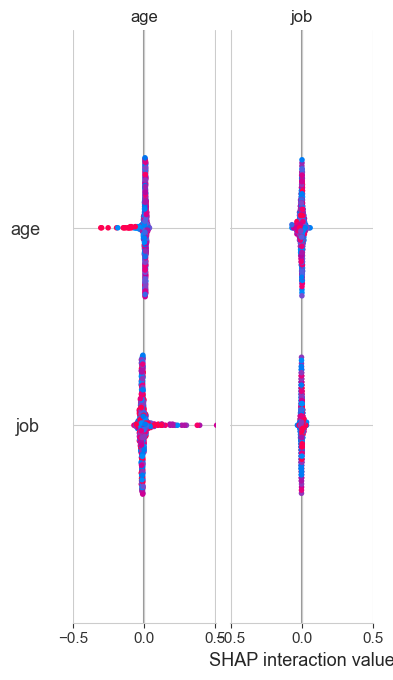

In [44]:
# Most reliable fix — use shap_values directly without indexing
shap.summary_plot(shap_values, X_sample, plot_type='bar', class_names=['No', 'Yes'])


Customer #1 | Actual: NO | Predicted: NO


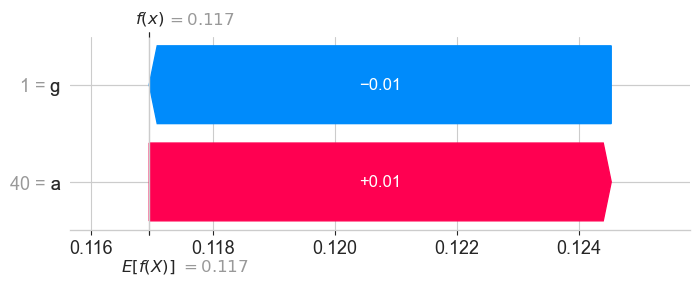


Customer #2 | Actual: NO | Predicted: NO


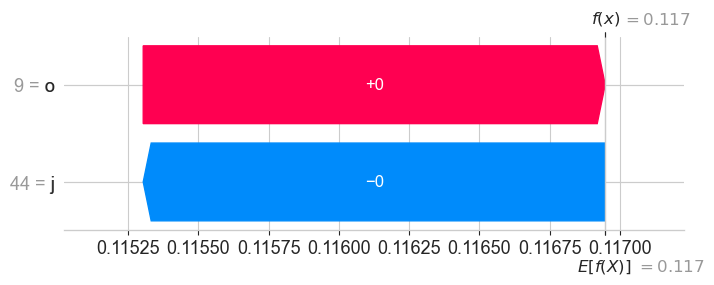


Customer #3 | Actual: NO | Predicted: NO


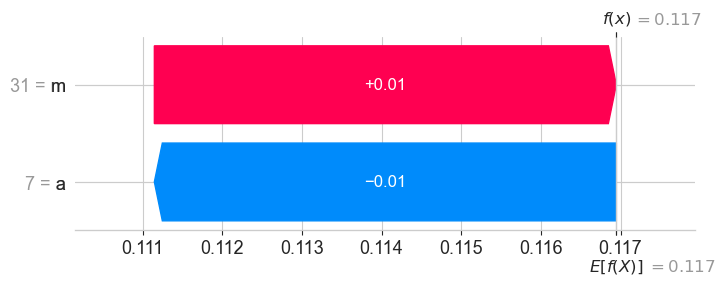


Customer #4 | Actual: NO | Predicted: NO


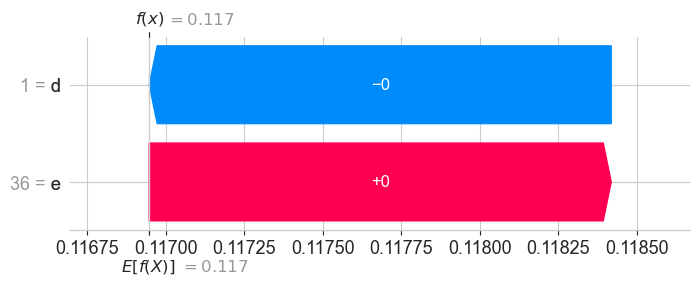


Customer #5 | Actual: NO | Predicted: NO


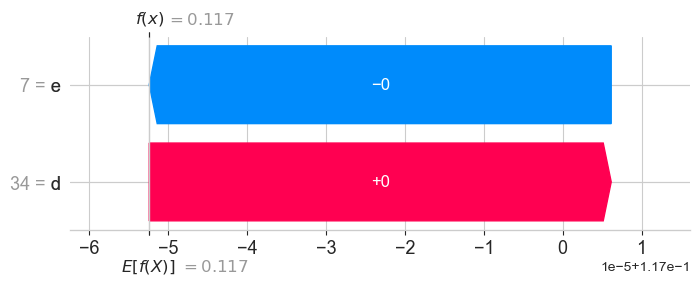

In [45]:
# Explain 5 individual customer predictions
shap_explanation = shap.Explanation(
    values=shap_values[1],
    base_values=explainer.expected_value[1],
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

for i in [0, 1, 2, 3, 4]:
    actual = 'YES' if y_test.iloc[i] == 1 else 'NO'
    predicted = 'YES' if rf_pred[i] == 1 else 'NO'
    print(f"\nCustomer #{i+1} | Actual: {actual} | Predicted: {predicted}")
    shap.plots.waterfall(shap_explanation[i], show=True)

In [46]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score': [
        round(f1_score(y_test, lr_pred), 4),
        round(f1_score(y_test, rf_pred), 4)
    ],
    'ROC-AUC': [
        round(auc_lr, 4),
        round(auc_rf, 4)
    ]
})
print(comparison.to_string(index=False))

              Model  F1-Score  ROC-AUC
Logistic Regression    0.3125   0.8547
      Random Forest    0.5101   0.9246


## Conclusion

- Random Forest outperformed Logistic Regression with higher F1 and AUC scores
- The most important features were: duration, balance, age, campaign, poutcome
- Customers with longer call duration are much more likely to subscribe
- Customers contacted fewer times during the campaign convert better
- Business recommendation: Focus calls on high-balance, older customers
  with positive previous campaign outcomes